# Main Assignment:
Write the complete code to select the best Regressor and classifier for the given dataset called diamonds (if you have a high end machine, you can use the whole dataset, else use the sample dataset provided in the link) or you can use Tips datset for Regression task and Iris dataset for Classification task.

You have to choose all possible models with their best or possible hyperparameters and compare them with each other and select the best model for the given dataset.

Your code should be complete and explained properly. for layman, each and every step of the code should be commented properly.

You code should also save the best model in the pickle file.

You should also write the code to load the pickle file and use it for prediction. in the last snippet of the code.


#  1. Classification Algorithms

In [ ]:
# 1. Import Required Libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-Learn Libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Ignore warning messages
import warnings
warnings.filterwarnings('ignore')

# Load the built-in Iris dataset
iris = load_iris()

# Convert dataset into Pandas DataFrame
df = pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names
)

In [8]:
# Check missing values
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [ ]:
#  Define Features and Target Variable

# Independent variables (Features) and  Dependent variable (Target)
X = iris.data
y = iris.target

# encoder the species column
le = LabelEncoder()
y = le.fit_transform(y)

# Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


In [ ]:
# Create Pipeline, Define Classifiers and Hyperparameters

# Import Required Libraries
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score


#  Create a Dictionary of Models
models = {'Logistic Regression': (LogisticRegression(),{'model__C': [0.01, 0.1, 1, 10, 100]}),
          'Support Vector Machine': (SVC(),{'model__kernel': ['linear', 'rbf', 'poly'],'model__C': [0.1, 1, 10],'model__gamma': ['scale', 'auto']}),
          'Decision Tree': (DecisionTreeClassifier(random_state=42),{'model__criterion': ['gini', 'entropy'],'model__max_depth': [None, 3, 5, 10],'model__splitter': ['best', 'random']}),
          'Random Forest': (RandomForestClassifier(random_state=42),{'model__n_estimators': [100, 200, 300],'model__max_depth': [None, 5, 10],'model__criterion': ['gini', 'entropy']}),
          'KNN': (KNeighborsClassifier(),{'model__n_neighbors': [3, 5, 7, 9],'model__weights': ['uniform', 'distance'],'model__metric': ['euclidean', 'manhattan', 'minkowski']}),
          'Gaussian Naive Bayes': (GaussianNB(),{}),
          'XGBoost': (XGBClassifier(random_state=42,eval_metric='mlogloss',use_label_encoder=False),
                    {'model__n_estimators': [100, 200],
                    'model__learning_rate': [0.01, 0.1],
                    'model__max_depth': [3, 5, 7]
                    }),
        #   'CatBoost': (CatBoostClassifier(verbose=False,random_seed=42),
        #     {   'model__iterations': [100, 200],
        #         'model__learning_rate': [0.01, 0.1],
        #         'model__depth': [3, 5, 7]
        #     })
}
# Create Empty Variables
best_model = None
best_model_name = ""
best_accuracy = 0
results = []

# 4. Loop Through Every Model
for name, (model, params) in models.items():
    # Create Pipeline
    pipeline = Pipeline(steps=[
                        ('scaler', StandardScaler()),
                        ('model', model)])
    # Create Grid Search
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        cv=5,
        scoring='accuracy',
        n_jobs=-1 )

    # Train the Model
    grid_search.fit(X_train, y_train)

    # Best Model of Current Algorithm
    current_model = grid_search.best_estimator_

    # Predict on the test set using the best fitted estimator from the grid search
    y_pred = grid_search.best_estimator_.predict(X_test)

    # Calculate Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Store Results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Best Parameters': grid_search.best_params_
    })

    # Save Best Model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = current_model
        best_model_name = name

Best Model : Logistic Regression
Best Accuracy : 1.0000

Best Hyperparameters
{'model__C': 1}


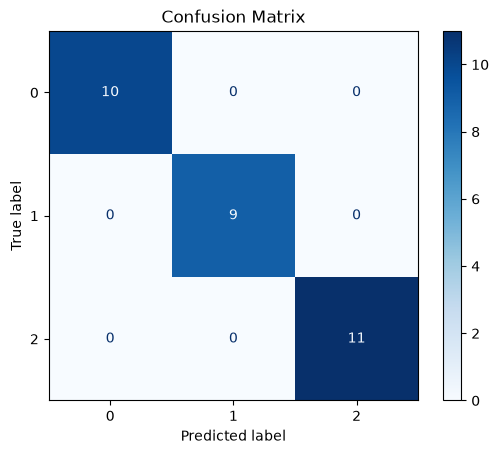

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Model Saved Successfully.
Model Loaded Successfully.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Predicted Species
0,5.1,3.5,1.4,0.2,0
1,6.5,3.0,5.2,2.0,2
2,7.2,3.2,6.0,1.8,2


In [15]:
# Compare Models, Select the Best Model,
# Save Best Model and Load it for Prediction

# Import Required Libraries
import pickle
from sklearn.metrics import (confusion_matrix, classification_report, ConfusionMatrixDisplay)

# Convert Results into DataFrame
results_df = pd.DataFrame(results)

# Sort the models based on Accuracy
results_df = results_df.sort_values(by='Accuracy',ascending=False).reset_index(drop=True)

# Display the comparison table
results_df

# 3. Print the Best Model

print(f"Best Model : {best_model_name}")
print(f"Best Accuracy : {best_accuracy:.4f}")

# 4. Best Hyperparameters

best_parameters = results_df.loc[
    results_df['Model'] == best_model_name,
    'Best Parameters'
].values[0]

print("\nBest Hyperparameters")
print(best_parameters)

# ==========================================================
# 5. Predict using the Best Model

y_pred = best_model.predict(X_test)

# 6. Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_).plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

# Save the Best Model
with open("./saved_models/best_iris_classifier.pkl", "wb") as file:
 
    pickle.dump(best_model, file)

print("Model Saved Successfully.")

# 9. Load the Saved Model
with open("./saved_models/best_iris_classifier.pkl", "rb") as file:

    loaded_model = pickle.load(file)

print("Model Loaded Successfully.")

# 10. Predict using the Loaded Model

loaded_predictions = loaded_model.predict(X_test)

# 11. Display First 10 Predictions

prediction_df = pd.DataFrame({
    "Actual Species": le.inverse_transform(y_test),
    "Predicted Species": le.inverse_transform(loaded_predictions)
})

prediction_df.head(10)

# 12. Predict for New Flower Samples
new_flowers = pd.DataFrame({

    'sepal length (cm)': [5.1, 6.5, 7.2],
    'sepal width (cm)': [3.5, 3.0, 3.2],
    'petal length (cm)': [1.4, 5.2, 6.0],
    'petal width (cm)': [0.2, 2.0, 1.8]

})

new_predictions = loaded_model.predict(new_flowers)

prediction_result = new_flowers.copy()

prediction_result["Predicted Species"] = new_predictions

prediction_result

# 2. Regression Algorithms

In [4]:
# 1. Import Required Libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-Learn Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Ignore warning messages
import warnings
warnings.filterwarnings('ignore')


In [5]:
# load the dataset 
df = sns.load_dataset('tips')
df.head()

# check the missing values
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [13]:
# split the data into features (X) and  target (y)
X = df.drop('tip', axis=1)
y = df['tip']

# label encoding the categorical variables
le = LabelEncoder()
categorical_cols = ['sex', 'smoker', 'day', 'time']
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# split the data into train and test set data into 80% and 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)


In [16]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [21]:
# Create Pipeline, Define Classifiers and Hyperparameters

# Import Required Libraries
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
#from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# create a dictnary of models

models = {
    'LinearRegression': (LinearRegression(),{}),
    'SVR': (SVR(),{}),
    'DecisionTreeRegressor': (DecisionTreeRegressor(),{}),
    'RandomForestRegressor': (RandomForestRegressor(), {}),
    'KNN': (KNeighborsRegressor(),{}),
    'XGBRegressor': (XGBRegressor(),{}),
    #'CatBoostRegressor': (CatBoostRegressor(),{})

}

# create a empty variables
best_model = None
best_model_name = ""
best_MAE = 0
results = []

for  name ,(model, params) in models.items():
    # create a pipeline 
    pipeline = Pipeline(steps=[
        ('Scaler', StandardScaler()),
        ('model', model)
    ])

    # create Grid search
    grid_search = GridSearchCV(
        estimator= pipeline,
        param_grid= params,
        cv=5,
        scoring='r2',
        n_jobs=1
    )

    # train the model
    grid_search.fit(X_train, y_train)

    # Best model of the current Algorithms
    current_model = grid_search.best_estimator_

    # Predict on the test set using the best fitted estimator from the grid search
    y_pred =  grid_search.best_estimator_.predict(X_test)

    # calculate accuracy scores of the model 
    MAE = mean_absolute_error(y_test, y_pred)

    # store the result
    results.append({ 
        'Model': name,
        'MAE': MAE,
        'Best parameter': grid_search.best_params_
        }
    )
 
    # save the model
    if MAE > best_MAE:
        best_MAE = MAE
        best_model = current_model
        best_model_name = model


In [36]:
# Compare Models, Select the Best Model,
# Save Best Model and Load it for Prediction

# Import Required Libraries
import pickle
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# convert the result into dataframe
result_df = pd.DataFrame(results)  # convert the 'results' list into a DataFrame
result_df = result_df.sort_values(by='MAE', ascending=True).reset_index(drop=True)

# sort the model base on accuracy
result_df = result_df.sort_values(by = 'MAE', ascending = False ).sort_index()

# desplay the result
result_df

# print the best model and best accuracy
print(f"Best Model : {best_model_name}")
print(f"Best Accuracy : {best_accuracy:.4f}")

# best Hyperparamter 
# Get the best hyperparameters for the selected best model
# best_parameters = result_df.loc[
#     result_df['Model'] == best_model_name,
#     'Best parameter'
# ]

# if best_parameters.empty:
#     raise ValueError("Best model not found in result_df.")

# best_parameters = best_parameters.iloc[0]

# # now display the hperparameter
# print("\nBest Hyperparameters")
# print(best_parameters)

# predic the best model
y_pred = best_model.predict(X_test)

# print the performing metric
print(name, 'MSE: ', mean_squared_error(y_test, y_pred))
print(name, 'R2: ', r2_score(y_test, y_pred))
print(name, 'MAE: ', mean_absolute_error(y_test, y_pred))
print('\n')

# save the best model

with open('./saved_models/best_tip_Regression.pkl', 'wb') as file:
     pickle.dump(best_model, file)
print('Model saved successfully')

# load the saved best model

with open('./saved_models/best_tip_Regression.pkl', 'rb') as file:
     loaded_model = pickle.load(file)
print('Model load Successfully')

#predict using the loaded_model
loaded_predictions = loaded_model.predict(X_test)

#  Display Predictions first convert into the pandas DataFrame

prediction_df = pd.DataFrame({
    "Actual tip": y_test.to_numpy(),
    "Predicted tip": loaded_predictions
})

prediction_df.head(10)

#  Predict for New tips Samples
new_tips = pd.DataFrame({
    'total_bill': [100, 150, 200],
    'sex': ['Male', 'Female', 'Male'],
    'smoker': ['Yes', 'Yes', 'No'],
    'day': ['Sun', 'Sun', 'Sun'],
    'time': ['Dinner', 'Dinner', 'Dinner'],
    'size': [2, 2, 3]
})

# Encode categorical columns using the same LabelEncoder fitted earlier
for col in ['sex', 'smoker', 'day', 'time']:
    new_tips[col] = le.fit_transform(new_tips[col])

new_predictions = loaded_model.predict(new_tips)

prediction_result = new_tips.copy()
prediction_result["Predicted Tip"] = new_predictions

prediction_result


Best Model : DecisionTreeRegressor()
Best Accuracy : 0.0000
XGBRegressor MSE:  1.5071081967213116
XGBRegressor R2:  -0.1328022150764725
XGBRegressor MAE:  0.9295081967213114


Model saved successfully
Model load Successfully


,total_bill,sex,smoker,day,time,size,Predicted Tip
0,100,1,1,0,0,2,10.0
1,150,0,1,0,0,2,10.0
2,200,1,0,0,0,3,10.0
